# Proyecto final: dataset real $4\times 4$ → QUBO → QAOA local y hardware opcional

Qubit.mx - QMexico Summer School 2026.

El objetivo del proyecto es transformar un problema real o semi-real bien justificado en un problema de **matching bipartito**, formularlo como **QUBO** y resolver una instancia pequeña con **QAOA local**.

## Entorno de ejecución en Google Colab

Ejecuten la siguiente celda al iniciar la sesión. Instala las librerías científicas usadas en el pipeline local y las librerías de Qiskit necesarias para la sección avanzada de IBM Quantum.

La parte base del proyecto no requiere cuenta de IBM Quantum. Qiskit se instala para evitar errores de importación si el equipo decide ejecutar la sección opcional de hardware real.

In [1]:
%%capture
%pip -q install numpy pandas scipy matplotlib qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

##  Lectura operativa de la rúbrica


```text
datos reales → entidades A y B → score S_ij → variables binarias x_ij → restricciones → QUBO → solución
```

La pregunta central no es “¿qué dataset encontré?”, sino:

> ¿Por qué este dataset puede modelarse de forma honesta como un matching bipartito 4×4?

##  Modelo matemático mínimo

Sean dos conjuntos de tamaño 4:

$$
A = \{a_1,a_2,a_3,a_4\}, \qquad
B = \{b_1,b_2,b_3,b_4\}.
$$

Cada variable binaria indica si se elige un emparejamiento entre $a_i$ y $b_j$:

$$
x_{ij}=\begin{cases}
1, & \text{si } a_i \text{ se asigna a } b_j,\\
0, & \text{en otro caso.}
\end{cases}
$$

La matriz $S\in\mathbb{R}^{4\times 4}$ contiene el beneficio, compatibilidad o score de cada posible match:

$$
S_{ij}=\text{score de asignar } a_i \text{ con } b_j.
$$

## Objetivo y restricciones

El problema de asignación uno-a-uno busca maximizar el score total:

$$
\max_x \sum_{i=1}^{4}\sum_{j=1}^{4} S_{ij}x_{ij}.
$$

Restricción por filas: cada elemento de $A$ se asigna exactamente una vez.

$$
\sum_{j=1}^{4} x_{ij}=1 \qquad \forall i\in\{1,2,3,4\}.
$$

Restricción por columnas: cada elemento de $B$ recibe exactamente una asignación.

$$
\sum_{i=1}^{4} x_{ij}=1 \qquad \forall j\in\{1,2,3,4\}.
$$

## Formulación QUBO

Un QUBO es una minimización cuadrática binaria. Convertimos el problema anterior en:

$$
E(x)=
-\sum_{i=1}^{4}\sum_{j=1}^{4} S_{ij}x_{ij}
+\lambda_A\sum_{i=1}^{4}\left(\sum_{j=1}^{4} x_{ij}-1\right)^2
+\lambda_B\sum_{j=1}^{4}\left(\sum_{i=1}^{4} x_{ij}-1\right)^2.
$$

El primer término premia scores altos. Los términos con $\lambda_A$ y $\lambda_B$ penalizan violaciones de las restricciones.

Si las penalizaciones son suficientemente grandes, el mínimo del QUBO corresponde a una asignación factible de alto score.

# Parte A — Búsqueda y justificación del dataset

Esta parte vale aproximadamente el 80% de la nota. Debe quedar documentada antes de ejecutar QAOA.

##  Importaciones y configuración

Objetivo: cargar librerías y fijar una semilla reproducible.

In [2]:
from collections import Counter
from itertools import permutations
from pathlib import Path
from typing import Any
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linear_sum_assignment
from IPython.display import display

SEED = 2026
rng = np.random.default_rng(SEED)

N_A = 4
N_B = 4
N_VARS = N_A * N_B

In [3]:
import pandas as pd
import numpy as np
import io

#  Cargamos tus datos base
data = """RUTA;Demanda anual base;N° de estaciones;Distancia de la ruta (km);Factor Socioeconómico
Buenavista-AIFA;165242;12;42.4;0.37
Queretaro-Irapuato;35824;6;111.0;0.30
Huehuetoca-Queretaro;1073;5;162.0;0.26
Xaltocan II-Pachuca;86311;8;115.0;0.07"""

df_base = pd.read_csv(io.StringIO(data), sep=";")

#  Construimos A_df (Rutas) y B_df (Zonas) con exactamente 4 filas
A_df = pd.DataFrame({
    'a_id': ['A1', 'A2', 'A3', 'A4'],
    'ruta_nombre': df_base['RUTA']
})

B_df = pd.DataFrame({
    'b_id': ['B1', 'B2', 'B3', 'B4'],
    'zona_nombre': [
        'Corredor Conurbado Norte (Zumpango-Cuautitlán)',
        'Macrorregión Industrial del Bajío (Querétaro)',
        'Nodo Logístico y Aeroportuario Extranjero (AIFA)',
        'Corredor Metropolitano de la Frontera Hidalgo (Pachuca)'
    ]
})

#  Función para calcular la matriz S de 4x4 parametrizada con alfa y beta
def calcular_matriz_score(df, alpha, beta):
    # Inicializamos una matriz de ceros de 4x4
    S_matrix = np.zeros((4, 4))

    # Calculamos la diagonal principal (i == j) explotando las columnas
    for i in range(4):
        demanda = df_base.loc[i, 'Demanda anual base']
        estaciones = df_base.loc[i, 'N° de estaciones']
        distancia = df_base.loc[i, 'Distancia de la ruta (km)']
        factor_socio = df_base.loc[i, 'Factor Socioeconómico']

        # Fórmula de utilidad multi-criterio
        densidad_estaciones = estaciones / distancia
        score_diagonal = demanda * (alpha * densidad_estaciones + beta * factor_socio)

        # Asignamos solo a la diagonal debido a que son zonas disjuntas
        S_matrix[i, i] = score_diagonal

    return S_matrix

# Parámetros de control (puedes cambiarlos y volver a correr la celda)
alpha = 0.6
beta = 0.4

S = calcular_matriz_score(df_base, alpha, beta)


# Opcional: Mostrar cómo quedó estructurada tu matriz S
print("Matriz S resultante (Diagonal principal activa):")
print(np.round(S, 2))

Matriz S resultante (Diagonal principal activa):
[[52515.78     0.       0.       0.  ]
 [    0.    5460.74     0.       0.  ]
 [    0.       0.     131.46     0.  ]
 [    0.       0.       0.    6019.25]]


## Validación mínima del dataset

Objetivo: detener la ejecución si la instancia no tiene tamaño $4\times 4$ o contiene valores no numéricos.

In [4]:
assert len(A_df) == 4, "A_df debe tener exactamente 4 filas."
assert len(B_df) == 4, "B_df debe tener exactamente 4 filas."
assert S.shape == (4, 4), "S debe tener forma (4, 4)."
assert np.isfinite(S).all(), "S contiene valores no finitos."

print("Dataset validado: A_df, B_df y S tienen formato compatible con matching 4x4.")

Dataset validado: A_df, B_df y S tienen formato compatible con matching 4x4.


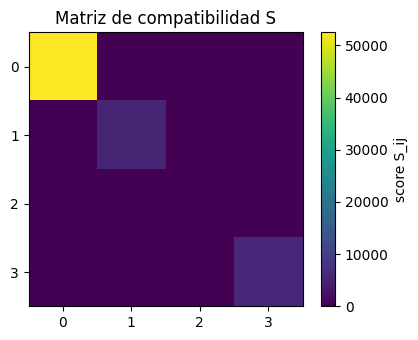

In [5]:
plt.figure(figsize=(4.5, 3.5))
plt.imshow(S)
plt.xticks(range(N_B), B_df.index)
plt.yticks(range(N_A), A_df.index)
plt.colorbar(label="score S_ij")
plt.title("Matriz de compatibilidad S")
plt.tight_layout()
plt.show()

##  Variables binarias $x_{ij}$

Objetivo: mapear cada posible match a una variable binaria y a un qubit lógico.

In [6]:
def var_index(i: int, j: int, n_b: int = N_B) -> int:
    return i * n_b + j

variables = []
for i, a_id in enumerate(A_df.index):
    for j, b_id in enumerate(B_df.index):
        variables.append({
            "k": var_index(i, j),
            "variable": f"x_{a_id}_{b_id}",
            "A": a_id,
            "B": b_id,
            "score": S[i, j],
        })

variables_df = pd.DataFrame(variables).set_index("k")
display(variables_df)

,variable,A,B,score
k,,,,
0,x_0_0,0,0,52515.778264
1,x_0_1,0,1,0.000000
2,x_0_2,0,2,0.000000
3,x_0_3,0,3,0.000000
4,x_1_0,1,0,0.000000
5,x_1_1,1,1,5460.739459
6,x_1_2,1,2,0.000000
7,x_1_3,1,3,0.000000
8,x_2_0,2,0,0.000000


##  Penalización QUBO

Objetivo: elegir penalizaciones suficientemente grandes para que violar restricciones sea más costoso que ganar score.

La regla usada aquí es conservadora para una instancia educativa pequeña.

In [7]:
def choose_penalty(score_matrix: np.ndarray) -> float:
    max_abs_score = float(np.max(np.abs(score_matrix)))
    return float(math.ceil(4.0 * max_abs_score + 1.0))

LAMBDA_A = choose_penalty(S)
LAMBDA_B = choose_penalty(S)

print("lambda_A =", LAMBDA_A)
print("lambda_B =", LAMBDA_B)

lambda_A = 210065.0
lambda_B = 210065.0


##  Construcción del QUBO

Usaremos la convención:

$$
E(x)=\sum_k Q_{kk}x_k+\sum_{k<\ell}Q_{k\ell}x_kx_\ell+\mathrm{offset}.
$$

`Q` guarda la diagonal y la parte triangular superior.

In [8]:
def add_exactly_one_penalty(Q: np.ndarray, group: list[int], penalty: float) -> float:
    """Agrega penalty * (sum(group) - 1)^2 al QUBO."""
    offset = float(penalty)

    for k in group:
        Q[k, k] += -penalty

    for pos, k in enumerate(group):
        for l in group[pos + 1:]:
            Q[k, l] += 2.0 * penalty

    return offset

In [9]:
def build_assignment_qubo(score_matrix: np.ndarray, lambda_a: float, lambda_b: float):
    S_local = np.asarray(score_matrix, dtype=float)
    n_a, n_b = S_local.shape
    Q = np.zeros((n_a * n_b, n_a * n_b), dtype=float)
    offset = 0.0

    for i in range(n_a):
        for j in range(n_b):
            k = var_index(i, j, n_b)
            Q[k, k] += -S_local[i, j]

    for i in range(n_a):
        group = [var_index(i, j, n_b) for j in range(n_b)]
        offset += add_exactly_one_penalty(Q, group, lambda_a)

    for j in range(n_b):
        group = [var_index(i, j, n_b) for i in range(n_a)]
        offset += add_exactly_one_penalty(Q, group, lambda_b)

    return Q, float(offset)

In [10]:
Q, qubo_offset = build_assignment_qubo(S, LAMBDA_A, LAMBDA_B)

print("Variables binarias:", N_VARS)
print("Offset QUBO:", qubo_offset)
print("Términos no nulos en Q:", int(np.count_nonzero(np.abs(Q) > 1e-12)))

Variables binarias: 16
Offset QUBO: 1680520.0
Términos no nulos en Q: 64


In [11]:
def qubo_terms_dataframe(Q: np.ndarray) -> pd.DataFrame:
    rows = []
    n = Q.shape[0]
    for k in range(n):
        if abs(Q[k, k]) > 1e-12:
            rows.append({"tipo": "lineal", "k": k, "l": k, "coeficiente": Q[k, k]})
        for l in range(k + 1, n):
            if abs(Q[k, l]) > 1e-12:
                rows.append({"tipo": "cuadrático", "k": k, "l": l, "coeficiente": Q[k, l]})
    return pd.DataFrame(rows)

qubo_terms_df = qubo_terms_dataframe(Q)
display(qubo_terms_df.head(20))

,tipo,k,l,coeficiente
0,lineal,0,0,-472645.778264
1,cuadrático,0,1,420130.000000
2,cuadrático,0,2,420130.000000
3,cuadrático,0,3,420130.000000
4,cuadrático,0,4,420130.000000
5,cuadrático,0,8,420130.000000
6,cuadrático,0,12,420130.000000
7,lineal,1,1,-420130.000000
8,cuadrático,1,2,420130.000000
9,cuadrático,1,3,420130.000000


##  Funciones de energía e interpretación

Objetivo: evaluar el QUBO, reconstruir matrices de asignación y revisar restricciones.

In [12]:
def qubo_energy(x: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> float:
    x = np.asarray(x, dtype=int)
    energy = float(offset)

    for k in range(len(x)):
        energy += Q[k, k] * x[k]

    for k in range(len(x)):
        for l in range(k + 1, len(x)):
            energy += Q[k, l] * x[k] * x[l]

    return float(energy)


def assignment_matrix(x: np.ndarray) -> np.ndarray:
    return np.asarray(x, dtype=int).reshape(N_A, N_B)

In [13]:
def is_feasible(x: np.ndarray) -> bool:
    M = assignment_matrix(x)
    return bool((M.sum(axis=1) == 1).all() and (M.sum(axis=0) == 1).all())


def assignment_score(x: np.ndarray, score_matrix: np.ndarray = S) -> float:
    return float(np.sum(assignment_matrix(x) * score_matrix))


def selected_pairs(x: np.ndarray) -> pd.DataFrame:
    M = assignment_matrix(x)
    rows = []
    for i, a_id in enumerate(A_df.index):
        for j, b_id in enumerate(B_df.index):
            if M[i, j] == 1:
                rows.append({"A": a_id, "B": b_id, "score": S[i, j]})
    return pd.DataFrame(rows)

##  Convención de bitstrings

Qiskit normalmente muestra los bitstrings en el orden del registro clásico, de izquierda a derecha. Internamente, el vector `x` usa el índice $k=iN_B+j$.

Estas funciones evitan errores de interpretación cuando se comparan conteos locales contra conteos de hardware real.

In [14]:
def x_to_qiskit_bitstring(x: np.ndarray) -> str:
    """Convierte un vector binario x al formato de bitstring que suele reportar Qiskit."""
    x = np.asarray(x, dtype=int)
    return "".join(str(int(bit)) for bit in x[::-1])


def index_to_qiskit_bitstring(index: int, n_bits: int = N_VARS) -> str:
    """Convierte un índice de estado computacional al bitstring equivalente."""
    return format(int(index), f"0{n_bits}b")


def decode_qiskit_bitstring(bitstring: str, n_bits: int = N_VARS) -> np.ndarray:
    """Convierte un bitstring de Qiskit al vector x usado por el QUBO."""
    clean = str(bitstring).replace(" ", "").strip()
    if clean.startswith("0b"):
        clean = clean[2:]
    if len(clean) < n_bits:
        clean = clean.zfill(n_bits)
    elif len(clean) > n_bits:
        clean = clean[-n_bits:]
    return np.array([int(bit) for bit in clean[::-1]], dtype=int)


def normalizar_conteos(counts: dict | Counter | None, n_bits: int = N_VARS) -> dict[str, int] | None:
    """Normaliza conteos agregados a bitstrings de longitud fija."""
    if counts is None:
        return None

    normalized: dict[str, int] = {}
    for key, value in counts.items():
        if value is None:
            continue

        if isinstance(key, (int, np.integer)):
            bitstring = index_to_qiskit_bitstring(int(key), n_bits)
        else:
            bitstring = str(key).replace(" ", "").strip()
            if bitstring.startswith("0b"):
                bitstring = bitstring[2:]
            if len(bitstring) < n_bits:
                bitstring = bitstring.zfill(n_bits)
            elif len(bitstring) > n_bits:
                bitstring = bitstring[-n_bits:]

        normalized[bitstring] = normalized.get(bitstring, 0) + int(value)

    return normalized

##  Validación clásica exacta

Objetivo: resolver por fuerza bruta las $2^{16}=65\,536$ configuraciones binarias.

Esto permite verificar si el QUBO fue construido correctamente.

In [15]:
def all_binary_vectors(n_bits: int) -> np.ndarray:
    integers = np.arange(2 ** n_bits, dtype=np.uint32)
    return ((integers[:, None] >> np.arange(n_bits)) & 1).astype(np.int8)


all_x = all_binary_vectors(N_VARS)
print("Número de configuraciones:", len(all_x))
print("Memoria de all_x en MB:", round(all_x.nbytes / 1024**2, 3))

Número de configuraciones: 65536
Memoria de all_x en MB: 1.0


In [16]:
def qubo_energy_many(X: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    energies = np.full(X.shape[0], float(offset), dtype=float)

    for k in range(Q.shape[0]):
        energies += Q[k, k] * X[:, k]

    for k in range(Q.shape[0]):
        for l in range(k + 1, Q.shape[0]):
            if abs(Q[k, l]) > 1e-12:
                energies += Q[k, l] * X[:, k] * X[:, l]

    return energies


energy_by_state = qubo_energy_many(all_x, Q, qubo_offset)
best_state_index = int(np.argmin(energy_by_state))
best_x_exact = all_x[best_state_index]

In [17]:
best_energy_exact = float(energy_by_state[best_state_index])
best_score_exact = assignment_score(best_x_exact)
best_feasible_exact = is_feasible(best_x_exact)

print("Mejor energía QUBO exacta:", best_energy_exact)
print("Score de la mejor solución:", best_score_exact)
print("¿La mejor solución es factible?", best_feasible_exact)

display(pd.DataFrame(assignment_matrix(best_x_exact), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_exact))

Mejor energía QUBO exacta: -64127.23418093729
Score de la mejor solución: 64127.23418093729
¿La mejor solución es factible? True


,0,1,2,3
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1


,A,B,score
0,0,0,52515.778264
1,1,1,5460.739459
2,2,2,131.462370
3,3,3,6019.254087


##  Validación adicional por permutaciones factibles

Objetivo: comparar el óptimo QUBO contra las 24 asignaciones uno-a-uno posibles.

Si el QUBO está bien penalizado, ambas soluciones deben coincidir.

In [18]:
best_perm = None
best_perm_score = -np.inf

for perm in permutations(range(N_B)):
    score = sum(S[i, perm[i]] for i in range(N_A))
    if score > best_perm_score:
        best_perm_score = float(score)
        best_perm = perm

x_perm = np.zeros(N_VARS, dtype=int)
for i, j in enumerate(best_perm):
    x_perm[var_index(i, j)] = 1

print("Mejor score factible por permutaciones:", best_perm_score)
print("Energía QUBO de esa asignación:", qubo_energy(x_perm, Q, qubo_offset))
print("¿Coincide con el óptimo QUBO?", np.array_equal(x_perm, best_x_exact))

display(pd.DataFrame(assignment_matrix(x_perm), index=A_df.index, columns=B_df.index))

Mejor score factible por permutaciones: 64127.23418093729
Energía QUBO de esa asignación: -64127.23418093729
¿Coincide con el óptimo QUBO? True


,0,1,2,3
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1


# Parte C — QAOA local ligero

La simulación QAOA local usa únicamente `numpy` y `scipy`.

No se usa IBM Quantum ni simuladores pesados. El estado cuántico tiene $2^{16}=65\,536$ amplitudes complejas, por lo que el consumo de RAM es bajo.

##  Estado inicial y costo diagonal

QAOA inicia en el estado uniforme:

$$
|+\rangle^{\otimes n}.
$$

Como el Hamiltoniano de costo es diagonal en la base computacional, la fase de costo se aplica directamente con el vector de energías QUBO.

In [19]:
N_STATES = 2 ** N_VARS

energy_center = float(np.mean(energy_by_state))
energy_scale = float(np.std(energy_by_state))
if energy_scale == 0:
    energy_scale = 1.0

phase_energy = (energy_by_state - energy_center) / energy_scale

print("Estados:", N_STATES)
print("Memoria del vector de estado complejo en MB:", round((N_STATES * np.dtype(np.complex128).itemsize) / 1024**2, 3))
print("Escala usada en fases QAOA:", round(energy_scale, 4))

Estados: 65536
Memoria del vector de estado complejo en MB: 1.0
Escala usada en fases QAOA: 1824127.0077


In [20]:
def plus_state(n_bits: int) -> np.ndarray:
    return np.ones(2 ** n_bits, dtype=np.complex128) / math.sqrt(2 ** n_bits)


def apply_cost_phase(state: np.ndarray, gamma: float) -> np.ndarray:
    return state * np.exp(-1j * gamma * phase_energy)

##  Mixer estándar

Usamos el mixer estándar:

$$
U_M(\beta)=\exp\left(-i\beta\sum_k X_k\right).
$$

Este mixer no preserva automáticamente la factibilidad. Por eso mediremos factibilidad después del muestreo.

In [21]:
def apply_mixer(state: np.ndarray, beta: float, n_bits: int) -> np.ndarray:
    state = state.copy()
    c = math.cos(beta)
    s = -1j * math.sin(beta)

    for k in range(n_bits):
        step = 1 << k
        block = step << 1
        view = state.reshape(-1, block)

        left = view[:, :step].copy()
        right = view[:, step:block].copy()

        view[:, :step] = c * left + s * right
        view[:, step:block] = s * left + c * right

    return state

##  Construcción del estado QAOA

Para $p=1$:

$$
|\psi(\gamma,\beta)\rangle
=
U_M(\beta)U_C(\gamma)|+\rangle^{\otimes n}.
$$

El código permite aumentar `QAOA_P`, pero para Colab se recomienda iniciar con `p=1`.

In [22]:
QAOA_P = 1

def qaoa_state(params: np.ndarray, p: int = QAOA_P) -> np.ndarray:
    params = np.asarray(params, dtype=float)
    state = plus_state(N_VARS)

    for layer in range(p):
        gamma = params[2 * layer]
        beta = params[2 * layer + 1]
        state = apply_cost_phase(state, gamma)
        state = apply_mixer(state, beta, N_VARS)

    return state


def qaoa_expected_energy(params: np.ndarray) -> float:
    state = qaoa_state(params, QAOA_P)
    probs = np.abs(state) ** 2
    return float(np.dot(probs, energy_by_state))

##  Optimización clásica de parámetros

Objetivo: encontrar ángulos $(\gamma,\beta)$ que reduzcan la energía esperada.

Para que la ejecución local sea ligera, se usan pocos reinicios y pocas iteraciones.

In [23]:
N_RESTARTS = 1
MAXITER = 25

restart_rows = []
best_result = None

for restart in range(N_RESTARTS):
    initial = rng.uniform(low=-np.pi, high=np.pi, size=2 * QAOA_P)

    result = minimize(
        qaoa_expected_energy,
        initial,
        method="COBYLA",
        options={"maxiter": MAXITER, "rhobeg": 0.7, "disp": False},
    )

    restart_rows.append({
        "restart": restart,
        "energia_esperada": float(result.fun),
        "parametros": np.round(result.x, 4),
        "evaluaciones": result.nfev,
    })

    if best_result is None or result.fun < best_result.fun:
        best_result = result

restart_df = pd.DataFrame(restart_rows)
display(restart_df)

,restart,energia_esperada,parametros,evaluaciones
0,0,783544.123195,"[-1.852, 0.4842]",25


In [24]:
best_params = np.asarray(best_result.x, dtype=float)
best_expected_energy = float(best_result.fun)

print("Mejores parámetros QAOA:", np.round(best_params, 6))
print("Energía esperada QAOA:", round(best_expected_energy, 6))
print("Óptimo clásico exacto:", round(best_energy_exact, 6))
print("Brecha esperada:", round(best_expected_energy - best_energy_exact, 6))

Mejores parámetros QAOA: [-1.852018  0.48417 ]
Energía esperada QAOA: 783544.123195
Óptimo clásico exacto: -64127.234181
Brecha esperada: 847671.357376


## Muestreo local

Objetivo: convertir la distribución QAOA en bitstrings observados.

Se toma el mejor bitstring observado por energía QUBO, no necesariamente el más frecuente.

In [25]:
qaoa_final_state = qaoa_state(best_params, QAOA_P)
qaoa_probs = np.abs(qaoa_final_state) ** 2
qaoa_probs = qaoa_probs / qaoa_probs.sum()

SHOTS_LOCAL = 2000
sampled_indices = rng.choice(N_STATES, size=SHOTS_LOCAL, replace=True, p=qaoa_probs)

# Conteos locales en formato comparable con Qiskit.
sample_counts = Counter(sampled_indices)
counts_local = Counter(index_to_qiskit_bitstring(int(idx), N_VARS) for idx in sampled_indices)

observed_indices = np.array(list(sample_counts.keys()), dtype=int)
best_observed_index = int(observed_indices[np.argmin(energy_by_state[observed_indices])])
best_x_qaoa = all_x[best_observed_index]

In [26]:
print("Shots locales:", SHOTS_LOCAL)
print("Bitstrings distintos observados:", len(sample_counts))
print("Mejor energía observada:", float(energy_by_state[best_observed_index]))
print("Score de la mejor muestra:", assignment_score(best_x_qaoa))
print("¿Mejor muestra factible?", is_feasible(best_x_qaoa))

display(pd.DataFrame(assignment_matrix(best_x_qaoa), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_qaoa))

Shots locales: 2000
Bitstrings distintos observados: 1299
Mejor energía observada: -64127.23418093729
Score de la mejor muestra: 64127.23418093729
¿Mejor muestra factible? True


,0,1,2,3
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1


,A,B,score
0,0,0,52515.778264
1,1,1,5460.739459
2,2,2,131.462370
3,3,3,6019.254087


##  Métricas probabilísticas de QAOA

Objetivo: reportar probabilidad de factibilidad y probabilidad del óptimo clásico bajo la distribución ideal simulada.

In [27]:
assignments_3d = all_x.reshape(N_STATES, N_A, N_B)
row_ok = (assignments_3d.sum(axis=2) == 1).all(axis=1)
col_ok = (assignments_3d.sum(axis=1) == 1).all(axis=1)
feasible_mask = row_ok & col_ok

prob_feasible = float(qaoa_probs[feasible_mask].sum())
prob_exact_optimum = float(qaoa_probs[best_state_index])

print("Probabilidad ideal de soluciones factibles:", round(prob_feasible, 6))
print("Probabilidad ideal del óptimo clásico exacto:", round(prob_exact_optimum, 6))

Probabilidad ideal de soluciones factibles: 0.026363
Probabilidad ideal del óptimo clásico exacto: 0.001152


In [28]:
top_indices = np.argsort(qaoa_probs)[::-1][:10]

top_rows = []
for rank, idx in enumerate(top_indices, start=1):
    x = all_x[idx]
    top_rows.append({
        "rank": rank,
        "probabilidad": qaoa_probs[idx],
        "energia_QUBO": energy_by_state[idx],
        "score": assignment_score(x),
        "factible": is_feasible(x),
    })

top_qaoa_df = pd.DataFrame(top_rows)
display(top_qaoa_df)

,rank,probabilidad,energia_QUBO,score,factible
0,1,0.002693,1.680520e+06,0.000000,False
1,2,0.002010,1.207874e+06,52515.778264,False
2,3,0.001912,1.260390e+06,0.000000,False
3,4,0.001912,1.260390e+06,0.000000,False
4,5,0.001912,1.260390e+06,0.000000,False
5,6,0.001912,1.260390e+06,0.000000,False
6,7,0.001910,1.260390e+06,0.000000,False
7,8,0.001910,1.260390e+06,0.000000,False
8,9,0.001902,1.254371e+06,6019.254087,False
9,10,0.001901,1.254929e+06,5460.739459,False


## Distribución de energías muestreadas

Objetivo: visualizar qué energías aparecen en las mediciones simuladas.

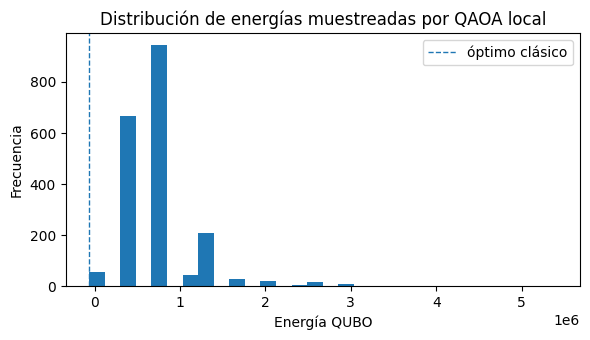

In [29]:
sampled_energies = energy_by_state[sampled_indices]

plt.figure(figsize=(6, 3.5))
plt.hist(sampled_energies, bins=30)
plt.axvline(best_energy_exact, linestyle="--", linewidth=1, label="óptimo clásico")
plt.xlabel("Energía QUBO")
plt.ylabel("Frecuencia")
plt.title("Distribución de energías muestreadas por QAOA local")
plt.legend()
plt.tight_layout()
plt.show()

##  Comparación final local

Objetivo: comparar clásico exacto contra QAOA local.

In [30]:
comparison_df = pd.DataFrame([
    {
        "método": "Clásico exacto",
        "energía": best_energy_exact,
        "score": best_score_exact,
        "factible": best_feasible_exact,
        "probabilidad_factible": np.nan,
        "probabilidad_óptimo": np.nan,
    },
    {
        "método": "QAOA local: mejor muestra",
        "energía": float(energy_by_state[best_observed_index]),
        "score": assignment_score(best_x_qaoa),
        "factible": is_feasible(best_x_qaoa),
        "probabilidad_factible": prob_feasible,
        "probabilidad_óptimo": prob_exact_optimum,
    },
])

display(comparison_df)

,método,energía,score,factible,probabilidad_factible,probabilidad_óptimo
0,Clásico exacto,-64127.234181,64127.234181,True,NaN,NaN
1,QAOA local: mejor muestra,-64127.234181,64127.234181,True,0.026363,0.001152


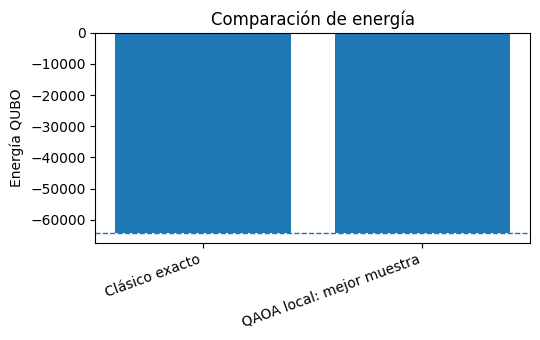

In [31]:
plt.figure(figsize=(5.5, 3.5))
plt.bar(comparison_df["método"], comparison_df["energía"])
plt.axhline(best_energy_exact, linestyle="--", linewidth=1)
plt.ylabel("Energía QUBO")
plt.title("Comparación de energía")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Parte E — Entrega obligatoria en GitHub

La entrega final es el enlace al repositorio GitHub del estudiante o del equipo. El repositorio debe contener el CSV en `data/`, un `README.md` justificando el dataset y el archivo `.ipynb` listo para abrirse en Google Colab.

In [32]:
counts_hardware =  []
print("Resumen automático")
print("------------------")
print("Instancia:")
print("Dataset:", f"{len(A_df)} x {len(B_df)}")
print("Mejor energía clásica:", best_energy_exact)
print("Mejor score clásico:", best_score_exact)
print("Mejor asignación clásica:")
display(selected_pairs(best_x_exact))

print("QAOA local")
print("----------")
print("Energía esperada:", best_expected_energy)
print("Mejor energía observada:", float(energy_by_state[best_observed_index]))
print("Probabilidad ideal de factibilidad:", prob_feasible)
print("Probabilidad ideal del óptimo clásico:", prob_exact_optimum)




Resumen automático
------------------
Instancia:
Dataset: 4 x 4
Mejor energía clásica: -64127.23418093729
Mejor score clásico: 64127.23418093729
Mejor asignación clásica:


,A,B,score
0,0,0,52515.778264
1,1,1,5460.739459
2,2,2,131.462370
3,3,3,6019.254087


QAOA local
----------
Energía esperada: 783544.1231946987
Mejor energía observada: -64127.23418093729
Probabilidad ideal de factibilidad: 0.02636347200162488
Probabilidad ideal del óptimo clásico: 0.0011515177762847213
